# Forecasting German Electricity Demand (2015-2020)


Data: Open Power System Data 60-minute file (`time_series_60min_singleindex.csv`), column
`DE_load_actual_entsoe_transparency`. Temperature: Open-Meteo archive API (Berlin).

Plan: prepare the data -> EDA -> benchmarks -> SARIMA -> SARIMAX with temperature ->
Random Forest / Gradient Boosting -> LSTM on hourly data -> compare everything.




## Setup

In [26]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
%matplotlib inline

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

TEST_WEEKS = 104     # 2-year forecast horizon
SEASON = 52          # weeks in a year

# --- Plot styling -----------------------------------------------------------

plt.rcParams.update({
    "figure.figsize": (7, 3.2),
    "figure.dpi": 130,
    "savefig.dpi": 130,
    "savefig.bbox": "tight",
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.edgecolor": "#888888",
    "grid.color": "#dddddd",
    "grid.linewidth": 0.8,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 9,
    "legend.framealpha": 0.9,
    "lines.linewidth": 1.6,
})

def tidy(axes):
    # Drop the top and right spines from one or several axes for a cleaner frame.
    for a in (axes if hasattr(axes, "__iter__") else [axes]):
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)

COLORS = {
    "actual": "#111111", "train": "#111111",
    "Mean": "#1f77b4", "Naive": "#ff7f0e", "Seasonal naive": "#2ca02c", "Drift": "#d62728",
    "SARIMA": "#d62728", "SARIMAX": "#9467bd",
    "Random Forest": "#2ca02c", "Gradient Boosting": "#ff7f0e", "LSTM": "#e377c2",
}

# every model's scores get appended here so i can compare at the end
results = []

def mase(y_true, y_pred, y_train, seasonality=SEASON):
    """Mean absolute scaled error: forecast MAE divided by the in-sample
    seasonal-naive MAE. MASE < 1 beats seasonal naive; MASE = 0 is perfect."""
    y_train = np.asarray(y_train, dtype=float)
    scale = np.abs(y_train[seasonality:] - y_train[:-seasonality]).mean()
    return np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))) / scale

def evaluate(name, y_true, y_pred, y_train=None):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    bias = np.mean(np.asarray(y_pred) - np.asarray(y_true))
    row = {"Model": name, "RMSE": rmse, "MAE": mae, "MAPE": mape, "Bias": bias}
    # MASE needs the training series; supply it where available (weekly models)
    if y_train is not None:
        row["MASE"] = mase(y_true, y_pred, y_train)
    results.append(row)
    extra = f"  MASE={row['MASE']:.3f}" if "MASE" in row else ""
    print(f"{name:22s}  RMSE={rmse:.3f}  MAE={mae:.3f}  MAPE={mape:.2f}%  Bias={bias:+.3f}{extra}")
    return rmse

---
## Part 1 - Load and prepare the data

In [27]:
df = pd.read_csv(
    "time_series_60min_singleindex.csv",
    usecols=["utc_timestamp", "DE_load_actual_entsoe_transparency"],
)

# the timestamps in UTC and convert to German local time.
# (The cet_cest_timestamp column is ambiguous at the autumn clock change,
#  so parsing UTC first is safer.)
df["time"] = pd.to_datetime(df["utc_timestamp"], utc=True).dt.tz_convert("Europe/Berlin")
load = df.set_index("time")["DE_load_actual_entsoe_transparency"].sort_index()

load = load["2015-01-01":]              # keep 2015 onwards, as the brief says
print("hourly rows:", len(load), " missing:", load.isna().sum())

# The one missing value is the very first row, and interpolate() cannot fill a
# leading gap (there is nothing before it), so we back-fill afterwards.
load = load.interpolate("time").bfill()
print("missing after filling:", load.isna().sum())

load = load / 1000                      # MW -> GW, nicer numbers to read

hourly rows: 50401  missing: 1
missing after filling: 0


In [28]:
# Bin the data up to daily and weekly
daily = load.resample("D").mean()
weekly = load.resample("W").mean()

# The first and last weeks of the file are incomplete, so droping them.
# Careful: the two clock-change weeks each year have 167 or 169 hours, not 168.
# i must KEEP those, otherwise the weekly series gets gaps and SARIMA breaks.
hours = load.resample("W").count()
weekly = weekly[hours >= 167]
weekly = weekly.asfreq("W")

print("weekly rows:", len(weekly), "|", weekly.index[0].date(), "->", weekly.index[-1].date())
print("any gaps?", weekly.isna().sum())
weekly.describe()

weekly rows: 299 | 2015-01-11 -> 2020-09-27
any gaps? 0


,DE_load_actual_entsoe_transparency
count,299.000000
mean,55.505791
std,3.743530
min,46.504399
25%,52.856446
50%,54.854899
75%,58.695286
max,63.600643


###  EDA

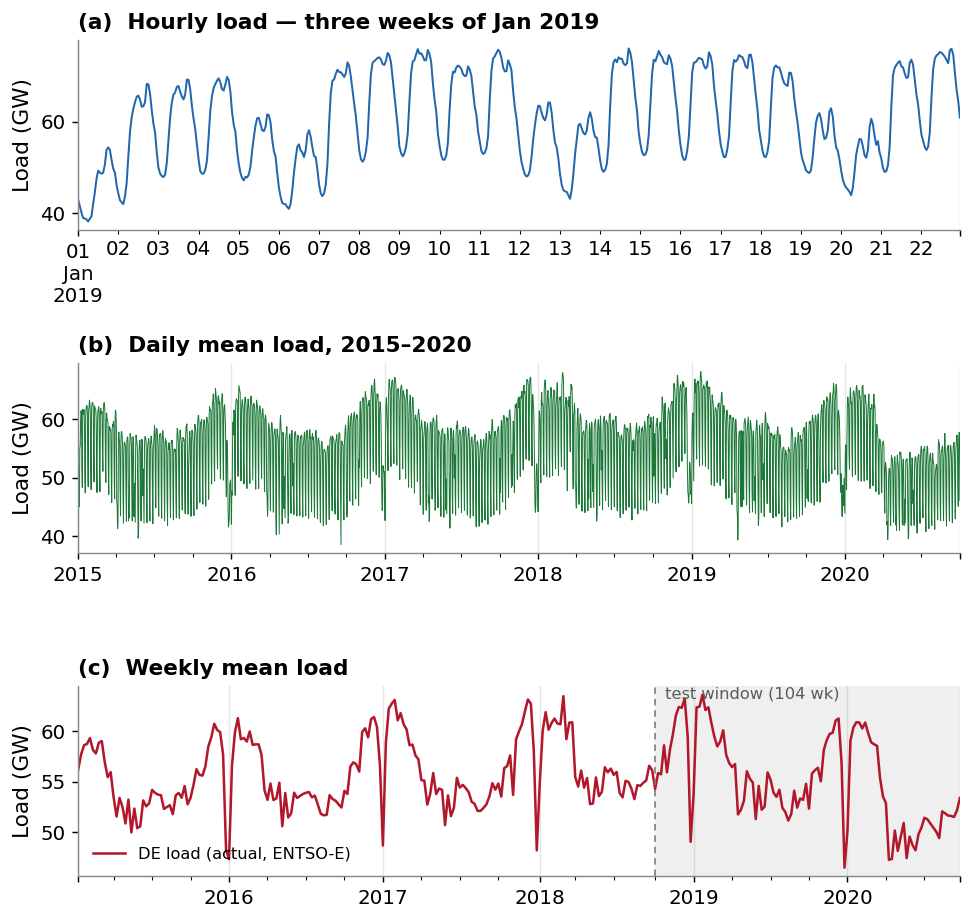

In [29]:
plt.rcParams.update({"axes.titlesize": 12, "axes.titleweight": "bold",
                     "grid.color": "#e6e6e6", "axes.edgecolor": "#8a8a8a",
                     "font.size": 10.5, "savefig.dpi": 200})
C = ["#2166AC", "#1B7837", "#B2182B"]          # blue / green / red
fig, ax = plt.subplots(3, 1, figsize=(7.6, 7.2))

load["2019-01-01":"2019-01-22"].plot(ax=ax[0], color=C[0], lw=1.1)
daily.plot(ax=ax[1], color=C[1], lw=0.55)
weekly.plot(ax=ax[2], color=C[2], lw=1.4, label="DE load (actual, ENTSO-E)")

x0 = weekly.index[-TEST_WEEKS]                  # shaded test window
ax[2].axvspan(x0, weekly.index[-1], color="#9e9e9e", alpha=0.16, lw=0)
ax[2].axvline(x0, color="#7a7a7a", lw=0.9, ls=(0, (4, 3)))
ax[2].text(x0, ax[2].get_ylim()[1], "  test window (104 wk)",
           va="top", fontsize=9, color="#5a5a5a")
ax[2].legend(loc="lower left", fontsize=9, frameon=False)

titles = ["(a)  Hourly load — three weeks of Jan 2019",
          "(b)  Daily mean load, 2015–2020",
          "(c)  Weekly mean load"]
for a, t in zip(ax, titles):
    a.set_title(t, loc="left"); a.set_ylabel("Load (GW)"); a.set_xlabel("")
    a.spines[["top", "right"]].set_visible(False)
    a.grid(axis="y"); a.margins(x=0.01)

fig.align_ylabels(ax); plt.tight_layout(h_pad=1.6)
plt.savefig("load_eda.png", bbox_inches="tight")
plt.show()

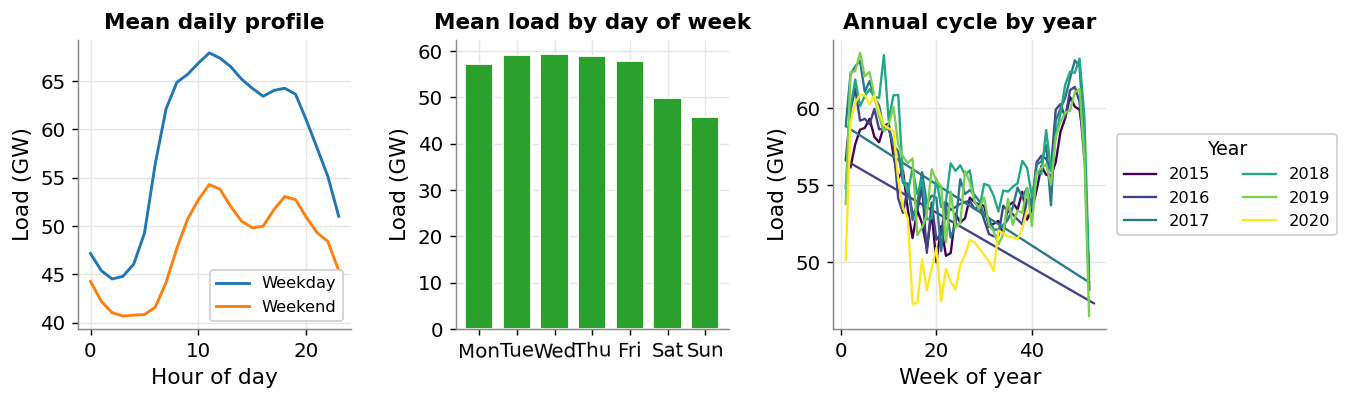

In [30]:
import matplotlib.cm as cm

# What seasonal patterns are there?
fig, ax = plt.subplots(1, 3, figsize=(10.5, 3.2))

# daily shape, weekday vs weekend
hourly_profile = load.groupby([load.index.dayofweek >= 5, load.index.hour]).mean().unstack(0)
hourly_profile.columns = ["Weekday", "Weekend"]
hourly_profile.plot(ax=ax[0], color=["#1f77b4", "#ff7f0e"])
ax[0].set_title("Mean daily profile")
ax[0].set_xlabel("Hour of day")
ax[0].set_ylabel("Load (GW)")
ax[0].legend(title="")

# day of week
dow = daily.groupby(daily.index.dayofweek).mean()
dow.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow.plot(kind="bar", ax=ax[1], color="#2ca02c", width=0.75, edgecolor="white")
ax[1].set_title("Mean load by day of week")
ax[1].set_ylabel("Load (GW)")
ax[1].tick_params(axis="x", rotation=1)

# yearly shape, one line per year
years = sorted(weekly.index.year.unique())
colors = cm.viridis(np.linspace(0, 1, len(years)))
for i, year in enumerate(years):
    group = weekly[weekly.index.year == year]
    ax[2].plot(group.index.isocalendar().week.values, group.values, lw=1.3, label=year, color=colors[i])
ax[2].set_title("Annual cycle by year")
ax[2].set_xlabel("Week of year")
ax[2].set_ylabel("Load (GW)")
ax[2].legend(title="Year", ncol=2, loc="center left", bbox_to_anchor=(1.01, 0.5))

tidy(ax)
plt.tight_layout()
plt.show()

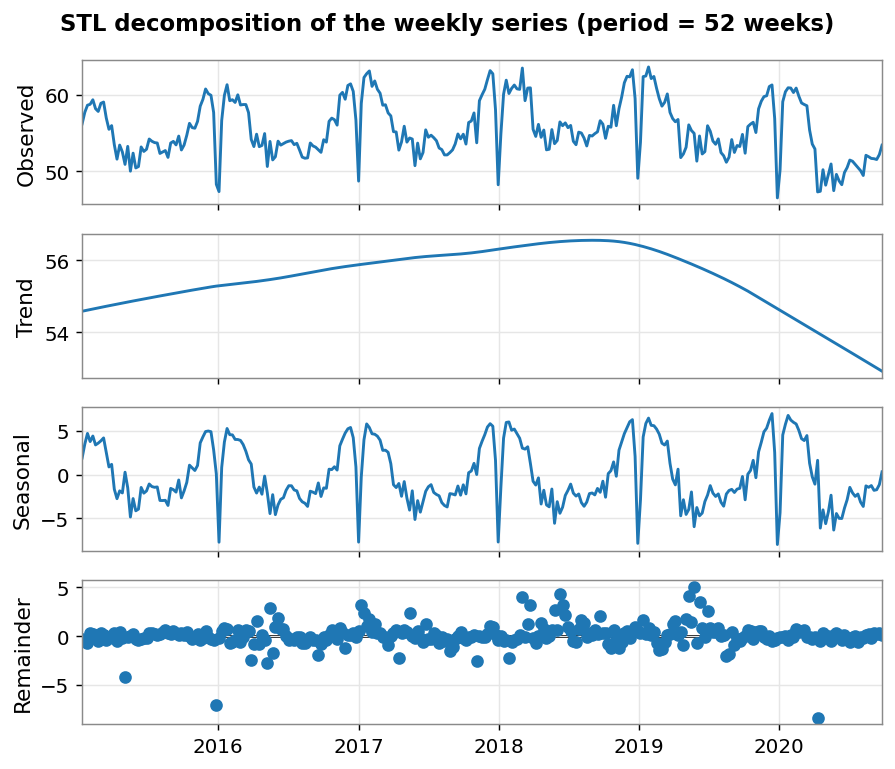

Component standard deviations (GW):
  observed  : 3.74
  trend     : 0.88
  seasonal  : 3.45
  remainder : 1.20

Seasonal strength: 0.884
Trend strength   : 0.437


In [31]:
# STL decomposition: split the weekly series into trend + seasonal + remainder
stl = STL(weekly, period=SEASON, robust=True).fit()

fig = stl.plot()
fig.set_size_inches(7, 6)

# stl.plot() labels the top panel with the Series name (the raw column name).
# Renameing the panels to clean words and drop the x-axis clutter.
panel_labels = ["Observed", "Trend", "Seasonal", "Remainder"]
for ax, lab in zip(fig.axes, panel_labels):
    ax.set_ylabel(lab)
    ax.set_title("")        # removeing the raw-column-name title on the top panel
    ax.set_xlabel("")

fig.suptitle("STL decomposition of the weekly series (period = 52 weeks)",
             fontweight="bold")
plt.tight_layout()
plt.show()

# Quantify how much each component explains - useful for the report.
print("Component standard deviations (GW):")
print(f"  observed  : {weekly.std():.2f}")
print(f"  trend     : {stl.trend.std():.2f}")
print(f"  seasonal  : {stl.seasonal.std():.2f}")
print(f"  remainder : {stl.resid.std():.2f}")

seasonal_strength = max(0, 1 - stl.resid.var() / (stl.seasonal + stl.resid).var())
trend_strength = max(0, 1 - stl.resid.var() / (stl.trend + stl.resid).var())
print(f"\nSeasonal strength: {seasonal_strength:.3f}")
print(f"Trend strength   : {trend_strength:.3f}")

### Test for non-stationarity

ADF null hypothesis = there IS a unit root (non-stationary).
KPSS null hypothesis = the series IS stationary.
So i want ADF p to be small and KPSS p to be large.

In [32]:
def check_stationarity(series, label):
    series = series.dropna()
    adf_p = adfuller(series, autolag="AIC")[1]
    kpss_p = kpss(series, regression="c", nlags="auto")[1]
    print(f"{label:32s} ADF p={adf_p:.4f}   KPSS p={kpss_p:.4f}")

check_stationarity(weekly, "original")
check_stationarity(weekly.diff(), "first difference (d=1)")
check_stationarity(weekly.diff(SEASON), "seasonal difference (D=1)")
check_stationarity(weekly.diff(SEASON).diff(), "seasonal + first difference")

original                         ADF p=0.0021   KPSS p=0.1000
first difference (d=1)           ADF p=0.0000   KPSS p=0.1000
seasonal difference (D=1)        ADF p=0.3795   KPSS p=0.0100
seasonal + first difference      ADF p=0.0000   KPSS p=0.1000


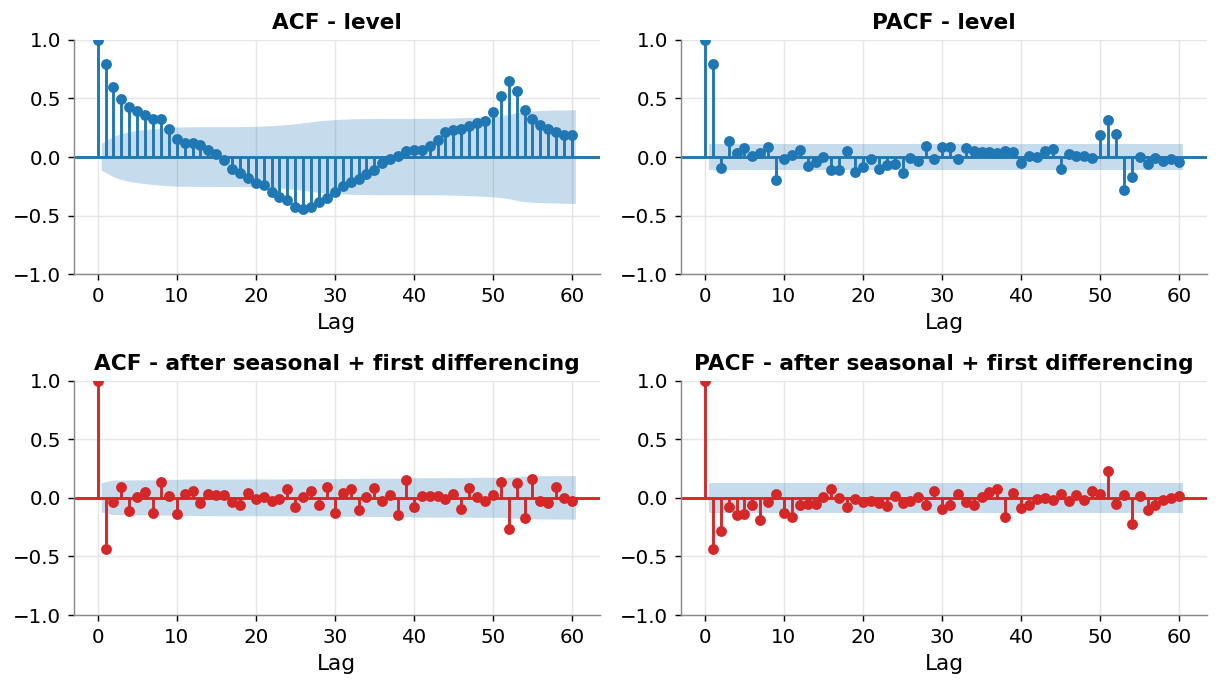

In [33]:
fig, ax = plt.subplots(2, 2, figsize=(9.5, 5.4))

plot_acf(weekly, lags=60, ax=ax[0, 0], title="ACF - level", color="#1f77b4", vlines_kwargs={"colors": "#1f77b4"})
plot_pacf(weekly, lags=60, ax=ax[0, 1], title="PACF - level", method="ywm", color="#1f77b4", vlines_kwargs={"colors": "#1f77b4"})

stationary = weekly.diff(SEASON).diff().dropna()
plot_acf(stationary, lags=60, ax=ax[1, 0], title="ACF - after seasonal + first differencing", color="#d62728", vlines_kwargs={"colors": "#d62728"})
plot_pacf(stationary, lags=60, ax=ax[1, 1], title="PACF - after seasonal + first differencing", method="ywm", color="#d62728", vlines_kwargs={"colors": "#d62728"})

for a in ax.ravel():
    a.set_xlabel("Lag")
    tidy(a)
plt.tight_layout()
plt.show()

---
## Part 2 - Benchmark models

Mean, Naive, Seasonal naive and Drift, forecasting 2 years ahead.

In [34]:
train = weekly[:-TEST_WEEKS]      # full 2015-onwards training set (used by Parts 3-6)
test = weekly[-TEST_WEEKS:]
h = len(test)

# Part 2 instruction: the BENCHMARKS are built from 2017 onwards, while every
# later model (SARIMA, SARIMAX, tree models, LSTM) keeps the full 2015 training
# set. Only the benchmark training window is shortened here.
bench_train = train[train.index >= "2017-01-01"]
print("full train weeks:", len(train), " benchmark train weeks:", len(bench_train),
      " test weeks:", h)

forecasts = {}   # keeping every model's forecast so we can plot them together later

# 1. Mean - average of the (2017-onwards) benchmark training data
forecasts["Mean"] = pd.Series(bench_train.mean(), index=test.index)

# 2. Naive - the last observed value
forecasts["Naive"] = pd.Series(bench_train.iloc[-1], index=test.index)

# 3. Seasonal naive - the value from the same week one year earlier
seasonal_values = [bench_train.iloc[-SEASON + (i % SEASON)] for i in range(h)]
forecasts["Seasonal naive"] = pd.Series(seasonal_values, index=test.index)

# 4. Drift - straight line whose slope is the average weekly change over the
# 2017-onwards window. It captures the strong 2017-2018 upward trend and so
# rises about 8 GW across the horizon.
slope = (bench_train.iloc[-1] - bench_train.iloc[0]) / (len(bench_train) - 1)
forecasts["Drift"] = pd.Series(
    bench_train.iloc[-1] + slope * np.arange(1, h + 1), index=test.index
)

# Benchmarks are scored against the 2017-onwards series for a like-for-like
# scaling in MASE, but on the same 104-week test window as every other model.
for name in ["Mean", "Naive", "Seasonal naive", "Drift"]:
    evaluate(name, test, forecasts[name], bench_train)

full train weeks: 195  benchmark train weeks: 92  test weeks: 104
Mean                    RMSE=4.513  MAE=3.894  MAPE=7.24%  Bias=+1.148  MASE=2.356
Naive                   RMSE=4.476  MAE=3.857  MAPE=7.15%  Bias=+0.989  MASE=2.334
Seasonal naive          RMSE=2.991  MAE=2.291  MAPE=4.36%  Bias=+1.748  MASE=1.387
Drift                   RMSE=8.011  MAE=6.514  MAPE=12.45%  Bias=+5.278  MASE=3.942


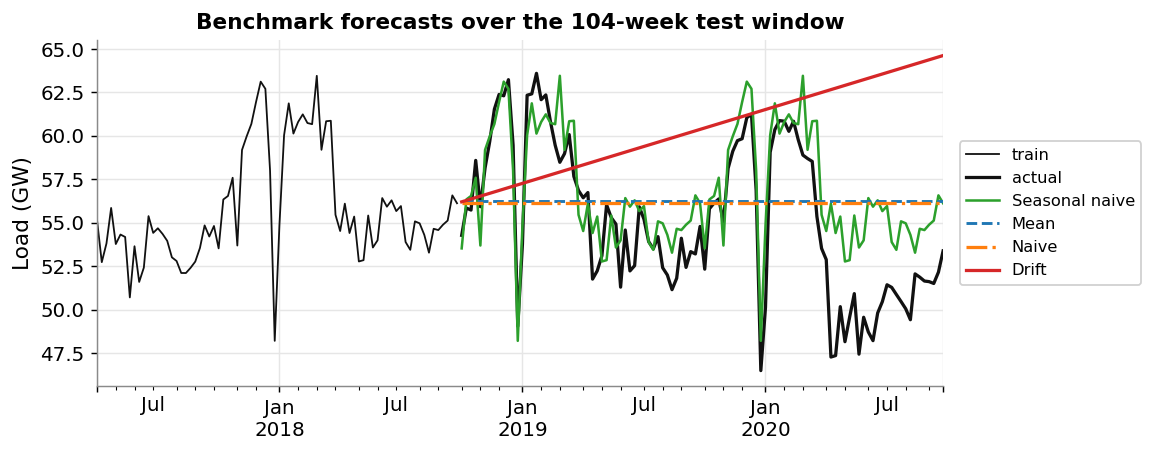

In [35]:
fig, ax = plt.subplots(figsize=(9, 3.6))

train[-78:].plot(ax=ax, color="#111111", lw=1.0, label="train")
test.plot(ax=ax, color="#111111", lw=1.8, label="actual")

# Mean and Naive are flat; Seasonal naive follows the yearly cycle; Drift now
# slopes upward (its slope is measured from 2017, see the benchmark cell above).
# Distinct colour + dash pattern + width keeps all four benchmarks readable.
styles = {
    "Mean":           dict(color="#1f77b4", ls="--",  lw=1.6),
    "Naive":          dict(color="#ff7f0e", ls="-.",  lw=1.8),
    "Seasonal naive": dict(color="#2ca02c", ls="-",   lw=1.4),
    "Drift":          dict(color="#d62728", ls="-",   lw=1.8),
}
for name in ["Seasonal naive", "Mean", "Naive", "Drift"]:
    forecasts[name].plot(ax=ax, label=name, **styles[name])

# The drift line captures the upward trend in load since 2017: it rises about
# 8.5 GW across the two-year horizon, in contrast to the flat Mean and Naive.
mid = len(test) // 2
"""ax.annotate(
    "Drift trends upward (slope from 2017):\n"
    "load rose steadily over 2017-2018",
    xy=(test.index[mid], forecasts["Drift"].iloc[mid]),
    xytext=(0.02, 0.80), textcoords="axes fraction",
    fontsize=7, color="#555555",
    arrowprops=dict(arrowstyle="->", color="#999999", lw=0.8),
)"""

ax.set_title("Benchmark forecasts over the 104-week test window")
ax.set_ylabel("Load (GW)")
ax.set_xlabel("")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
tidy(ax)
plt.tight_layout()
plt.show()

---
## Part 3 - SARIMA

Grid search over p = 0..6, d = 0..2, q = 0..6 and pick the lowest AIC.
The seasonal part is fixed at (1,1,1,52) while  i search, then refined afterwards.

 147 models with a 52-week season takes.

In [36]:
aic_scores = []

for p in range(0, 7):
    for d in range(0, 3):
        for q in range(0, 7):
            try:
                model = SARIMAX(
                    train,
                    order=(p, d, q),
                    seasonal_order=(1, 1, 1, SEASON),
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                ).fit(disp=False, maxiter=35)
                aic_scores.append({"p": p, "d": d, "q": q, "AIC": model.aic})
            except Exception:
                pass          # some combinations fail to converge - just skip them

    print("finished p =", p)

aic_table = pd.DataFrame(aic_scores).sort_values("AIC").reset_index(drop=True)
best = aic_table.iloc[0]
best_order = (int(best.p), int(best.d), int(best.q))
print("\nbest order:", best_order, " AIC =", round(best.AIC, 2))
aic_table.head()

finished p = 0
finished p = 1
finished p = 2
finished p = 3
finished p = 4
finished p = 5
finished p = 6

best order: (1, 1, 6)  AIC = 297.57


,p,d,q,AIC
0,1,1,6,297.570925
1,0,1,6,299.096479
2,2,1,6,299.464548
3,3,1,6,299.640726
4,1,0,6,301.502203


In [37]:
# Now trying the seasonal orders around the winner
seasonal_scores = []

for P in [0, 1]:
    for D in [0, 1]:
        for Q in [0, 1]:
            try:
                model = SARIMAX(
                    train,
                    order=best_order,
                    seasonal_order=(P, D, Q, SEASON),
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                ).fit(disp=False, maxiter=35)
                seasonal_scores.append({"P": P, "D": D, "Q": Q, "AIC": model.aic})
            except Exception:
                pass

seasonal_table = pd.DataFrame(seasonal_scores).sort_values("AIC").reset_index(drop=True)
b = seasonal_table.iloc[0]
best_seasonal = (int(b.P), int(b.D), int(b.Q), SEASON)
print("best seasonal order:", best_seasonal)
seasonal_table.head()

best seasonal order: (1, 1, 1, 52)


,P,D,Q,AIC
0,1,1,1,297.570925
1,0,1,1,299.173871
2,1,1,0,322.457068
3,0,1,0,526.182103
4,1,0,0,540.812632


In [38]:
# Fitting the final SARIMA and forecast the test period
sarima = SARIMAX(
    train,
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=200)

print(f"SARIMA{best_order}{best_seasonal}   AIC = {sarima.aic:.2f}")

sarima_result = sarima.get_forecast(steps=h)
forecasts["SARIMA"] = sarima_result.predicted_mean
conf_int = sarima_result.conf_int()

evaluate("SARIMA", test, forecasts["SARIMA"], train)

# how often does the real value fall inside the 95% interval?
inside = ((test >= conf_int.iloc[:, 0]) & (test <= conf_int.iloc[:, 1])).mean() * 100
print("95% interval coverage:", round(inside, 1), "%  (should be ~95%)")

SARIMA(1, 1, 6)(1, 1, 1, 52)   AIC = 297.54
SARIMA                  RMSE=4.029  MAE=3.298  MAPE=6.26%  Bias=+3.134  MASE=2.437
95% interval coverage: 70.2 %  (should be ~95%)


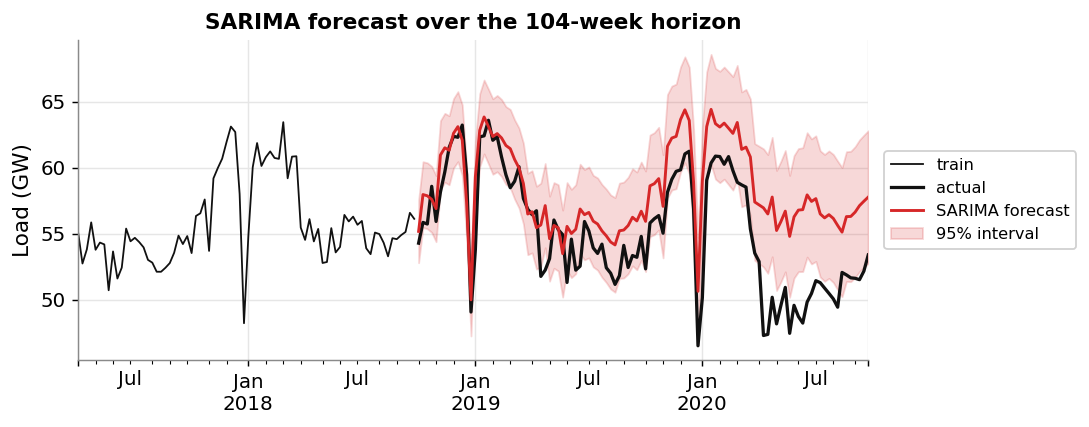

In [39]:
fig, ax = plt.subplots(figsize=(8.5, 3.4))

train[-78:].plot(ax=ax, color="#111111", lw=1.0, label="train")
test.plot(ax=ax, color="#111111", lw=1.8, label="actual")
forecasts["SARIMA"].plot(ax=ax, color="#d62728", lw=1.6, label="SARIMA forecast")
ax.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                color="#d62728", alpha=0.18, label="95% interval")

ax.set_title("SARIMA forecast over the 104-week horizon")
ax.set_ylabel("Load (GW)")
ax.set_xlabel("")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
tidy(ax)
plt.tight_layout()
plt.show()

### Checking the residuals

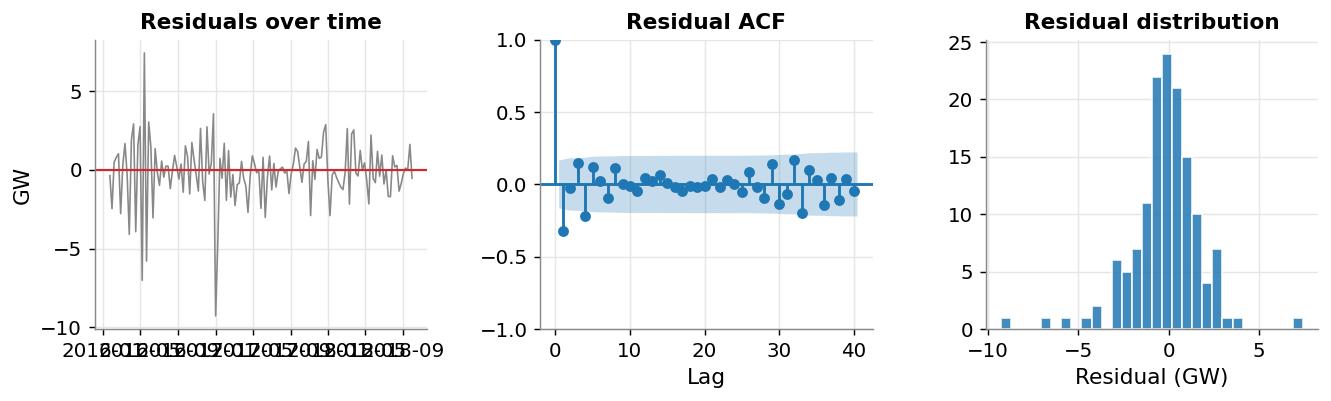

      lb_stat  lb_pvalue
12  31.393948   0.001715
24  33.018696   0.103680
52  73.057301   0.028637


In [40]:
residuals = sarima.resid[SEASON + 2:]     # skip the start-up values

fig, ax = plt.subplots(1, 3, figsize=(10.5, 3.2))
ax[0].plot(residuals.index, residuals.values, color="#888888", lw=0.9)
ax[0].axhline(0, color="#d62728", lw=1.2)
ax[0].set_title("Residuals over time")
ax[0].set_ylabel("GW")
ax[0].set_xlabel("")

plot_acf(residuals, lags=40, ax=ax[1], title="Residual ACF",
         color="#1f77b4", vlines_kwargs={"colors": "#1f77b4"})
ax[1].set_xlabel("Lag")

ax[2].hist(residuals, bins=30, color="#1f77b4", alpha=0.85, edgecolor="white")
ax[2].set_title("Residual distribution")
ax[2].set_xlabel("Residual (GW)")

for a in ax:
    tidy(a)
plt.tight_layout()
plt.show()

from statsmodels.stats.diagnostic import acorr_ljungbox
print(acorr_ljungbox(residuals, lags=[12, 24, 52]))

---
## Part 4 - Add temperature (SARIMAX)

Download Berlin temperature and use it as an exogenous regressor.
Because we use the *observed* test-period temperature (not a weather forecast),
this is an **explanatory / conditional forecast**, not a true operational one.

In [41]:
def get_temperature(start_date, end_date, lat=52.52, lon=13.41):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "daily": "temperature_2m_mean",
        "timezone": "Europe/Berlin",
    }
    data = requests.get(url, params=params).json()["daily"]
    temp = pd.DataFrame({
        "date": pd.to_datetime(data["time"]),
        "temp": data["temperature_2m_mean"],
    })
    return temp.set_index("date")["temp"]

temp_daily = get_temperature(str(load.index.min().date()), str(load.index.max().date()))
temp_daily.index = temp_daily.index.tz_localize("Europe/Berlin")
print(len(temp_daily), "days of temperature downloaded")
temp_daily.head()

2101 days of temperature downloaded


,temp
date,
2015-01-01 00:00:00+01:00,2.8
2015-01-02 00:00:00+01:00,4.6
2015-01-03 00:00:00+01:00,3.9
2015-01-04 00:00:00+01:00,3.0
2015-01-05 00:00:00+01:00,2.7


In [42]:
# Building the weekly feature table
features = pd.DataFrame(index=weekly.index)

features["temp_mean"] = temp_daily.resample("W").mean()
features["temp_min"] = temp_daily.resample("W").min()
features["temp_max"] = temp_daily.resample("W").max()

# Heating / cooling degree days: demand goes up when it is cold, and (a bit) when it is hot
features["heating_degree"] = np.maximum(15.5 - temp_daily, 0).resample("W").sum()
features["cooling_degree"] = np.maximum(temp_daily - 22.0, 0).resample("W").sum()

# Lagged temperature. shift(1) only looks BACKWARDS - week t gets week t-1's value,
# so no future information can leak into the model. The NaNs it creates land at the
# START of the data (in the training set), never in the test set.
features["temp_lag1"] = features["temp_mean"].shift(1)
features["temp_lag2"] = features["temp_mean"].shift(2)
features["hdd_lag1"] = features["heating_degree"].shift(1)

# Calendar features - sin/cos of the week number capture the yearly cycle smoothly
week_no = features.index.isocalendar().week.astype(int).values
features["week_sin"] = np.sin(2 * np.pi * week_no / 52)
features["week_cos"] = np.cos(2 * np.pi * week_no / 52)
features["week_sin2"] = np.sin(4 * np.pi * week_no / 52)   # second harmonic
features["week_cos2"] = np.cos(4 * np.pi * week_no / 52)
features["trend"] = np.arange(len(features))

# German public holidays
import holidays
german_holidays = holidays.Germany(years=range(2014, 2022))
all_days = pd.date_range(weekly.index[0] - pd.Timedelta(days=7), weekly.index[-1],
                         freq="D", tz="Europe/Berlin")
is_holiday = pd.Series([1.0 if d.date() in german_holidays else 0.0 for d in all_days],
                       index=all_days)
features["holiday_days"] = is_holiday.resample("W").sum().reindex(features.index)
features["has_holiday"] = (features["holiday_days"] > 0).astype(float)

features = features.interpolate()
features.head()

,temp_mean,temp_min,temp_max,heating_degree,cooling_degree,temp_lag1,temp_lag2,hdd_lag1,week_sin,week_cos,week_sin2,week_cos2,trend,holiday_days,has_holiday
time,,,,,,,,,,,,,,,
2015-01-11 00:00:00+01:00,3.885714,1.2,8.5,81.3,0.0,NaN,NaN,NaN,0.239316,0.970942,0.464723,0.885456,0,0.0,0.0
2015-01-18 00:00:00+01:00,4.900000,-0.8,9.2,74.2,0.0,3.885714,NaN,81.3,0.354605,0.935016,0.663123,0.748511,1,0.0,0.0
2015-01-25 00:00:00+01:00,0.028571,-0.7,0.9,108.3,0.0,4.900000,3.885714,74.2,0.464723,0.885456,0.822984,0.568065,2,0.0,0.0
2015-02-01 00:00:00+01:00,1.414286,-0.1,2.8,98.6,0.0,0.028571,4.900000,108.3,0.568065,0.822984,0.935016,0.354605,3,0.0,0.0
2015-02-08 00:00:00+01:00,-1.228571,-2.6,0.7,117.1,0.0,1.414286,0.028571,98.6,0.663123,0.748511,0.992709,0.120537,4,0.0,0.0


In [43]:
# How well does each feature correlate with load?
pd.concat([weekly.rename("load"), features], axis=1).corr()["load"].sort_values()

,load
temp_mean,-0.652525
temp_max,-0.642778
temp_min,-0.638399
temp_lag1,-0.628647
temp_lag2,-0.571044
holiday_days,-0.456453
has_holiday,-0.437896
cooling_degree,-0.162005
trend,-0.077742
week_cos2,0.056250


In [44]:
exog_columns = ["temp_mean", "heating_degree", "cooling_degree", "temp_lag1", "holiday_days"]

# temp_lag1 is NaN in the very first week (nothing precedes it), so droping that row.
# Joining load and features and then dropping NaN keeps y and X perfectly aligned.
sx = pd.concat([weekly.rename("load"), features[exog_columns]], axis=1).dropna()

y_sx = sx["load"]
X_sx = sx[exog_columns]

y_sx_train, y_sx_test = y_sx[:-TEST_WEEKS], y_sx[-TEST_WEEKS:]
X_sx_train, X_sx_test = X_sx[:-TEST_WEEKS], X_sx[-TEST_WEEKS:]

sarimax = SARIMAX(
    y_sx_train,
    exog=X_sx_train,
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=200)     # more iterations: the exog model needs them to converge

print(f"SARIMAX AIC = {sarimax.aic:.2f}   (SARIMA was {sarima.aic:.2f})")

forecasts["SARIMAX"] = sarimax.get_forecast(
    steps=len(y_sx_test), exog=X_sx_test
).predicted_mean
evaluate("SARIMAX (+temp)", y_sx_test, forecasts["SARIMAX"], train)

print("\nexogenous coefficients:")
print(sarimax.params[exog_columns])

SARIMAX AIC = 241.48   (SARIMA was 297.54)
SARIMAX (+temp)         RMSE=3.675  MAE=2.928  MAPE=5.58%  Bias=+2.854  MASE=2.163

exogenous coefficients:
temp_mean         0.351210
heating_degree    0.081519
cooling_degree   -0.069685
temp_lag1        -0.010575
holiday_days     -1.807041
dtype: float64


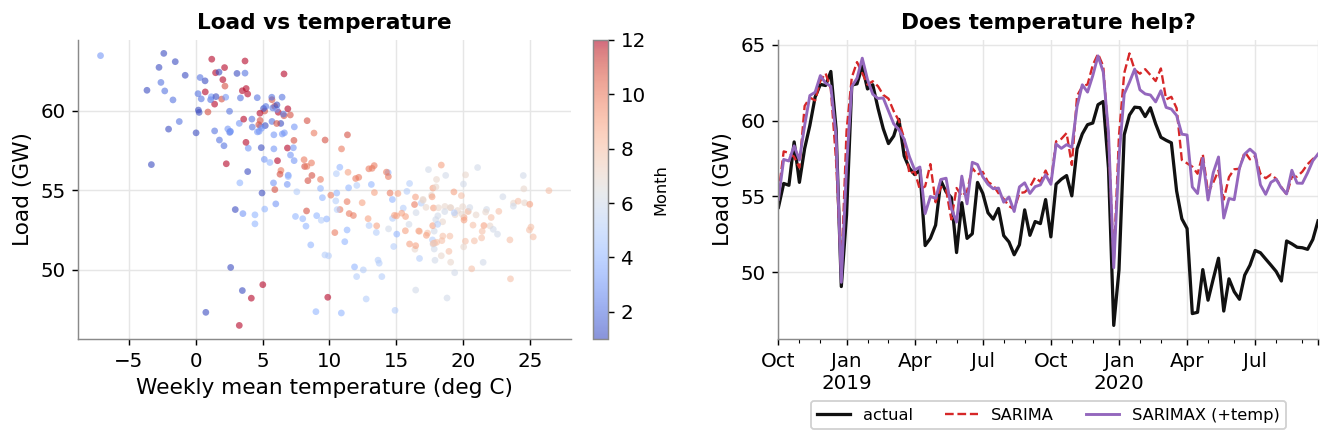

In [45]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.6))

sc = ax[0].scatter(features["temp_mean"], weekly, s=14, alpha=0.6,
                   c=weekly.index.month, cmap="coolwarm", edgecolor="none")
ax[0].set_xlabel("Weekly mean temperature (deg C)")
ax[0].set_ylabel("Load (GW)")
ax[0].set_title("Load vs temperature")
cbar = fig.colorbar(sc, ax=ax[0], fraction=0.046, pad=0.04)
cbar.set_label("Month", fontsize=9)

test.plot(ax=ax[1], color="#111111", lw=1.8, label="actual")
forecasts["SARIMA"].plot(ax=ax[1], color="#d62728", ls="--", lw=1.3, label="SARIMA")
forecasts["SARIMAX"].plot(ax=ax[1], color="#9467bd", lw=1.6, label="SARIMAX (+temp)")
ax[1].set_title("Does temperature help?")
ax[1].set_ylabel("Load (GW)")
ax[1].set_xlabel("")
ax[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3)

tidy(ax)
plt.tight_layout()
plt.show()

---
## Part 5 - Feature-based models (Random Forest / Gradient Boosting)

Note there are **no lagged load features**. We are forecasting 104 weeks ahead, so we
would not know last week's load at the forecast origin. Everything here is a calendar
or temperature variable.

In [46]:
feature_columns = [
    "temp_mean", "temp_min", "temp_max",
    "heating_degree", "cooling_degree",
    "temp_lag1", "temp_lag2", "hdd_lag1",
    "week_sin", "week_cos", "week_sin2", "week_cos2",
    "trend", "holiday_days", "has_holiday",
]

data = pd.concat([weekly.rename("load"), features[feature_columns]], axis=1).dropna()

y = data["load"]
X = data[feature_columns]

X_train, X_test = X[:-TEST_WEEKS], X[-TEST_WEEKS:]
y_train, y_test = y[:-TEST_WEEKS], y[-TEST_WEEKS:]

print("training on", X_train.shape[0], "weeks with", X_train.shape[1], "features")

def tune(model, grid, name):
    '''Grid-search a model with TimeSeriesSplit and return the best fitted estimator.

    We must NOT use ordinary K-fold here. Shuffling the folds would let the model
    train on weeks that come *after* the weeks it is validated on, which is leakage.
    TimeSeriesSplit always validates on a block that comes later than the training block.
    '''
    search = GridSearchCV(
        model, grid, cv=TimeSeriesSplit(n_splits=4),
        scoring="neg_root_mean_squared_error", n_jobs=-1,
    )
    search.fit(X_train, y_train)
    print(f"{name}: searched {len(search.cv_results_['params'])} combinations")
    print(f"  best params  : {search.best_params_}")
    print(f"  best CV RMSE : {-search.best_score_:.3f}")
    print()
    return search.best_estimator_


rf = tune(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    {"n_estimators": [300, 500],
     "max_depth": [None, 8, 14],
     "min_samples_leaf": [1, 2, 4],
     "max_features": [0.5, 1.0]},
    "Random Forest",
)

gb = tune(
    GradientBoostingRegressor(random_state=42),
    {"n_estimators": [300, 500],
     "learning_rate": [0.02, 0.05, 0.1],
     "max_depth": [2, 3, 4],
     "subsample": [0.8, 1.0]},
    "Gradient Boosting",
)

forecasts["Random Forest"] = pd.Series(rf.predict(X_test), index=y_test.index)
evaluate("Random Forest", y_test, forecasts["Random Forest"], train)

forecasts["Gradient Boosting"] = pd.Series(gb.predict(X_test), index=y_test.index)
evaluate("Gradient Boosting", y_test, forecasts["Gradient Boosting"], train)

training on 193 weeks with 15 features
Random Forest: searched 36 combinations
  best params  : {'max_depth': 8, 'max_features': 1.0, 'min_samples_leaf': 1, 'n_estimators': 500}
  best CV RMSE : 1.874

Gradient Boosting: searched 36 combinations
  best params  : {'learning_rate': 0.02, 'max_depth': 2, 'n_estimators': 500, 'subsample': 0.8}
  best CV RMSE : 1.606

Random Forest           RMSE=2.846  MAE=2.154  MAPE=4.14%  Bias=+1.486  MASE=1.591
Gradient Boosting       RMSE=2.881  MAE=2.147  MAPE=4.14%  Bias=+1.760  MASE=1.587


np.float64(2.8808010262408232)

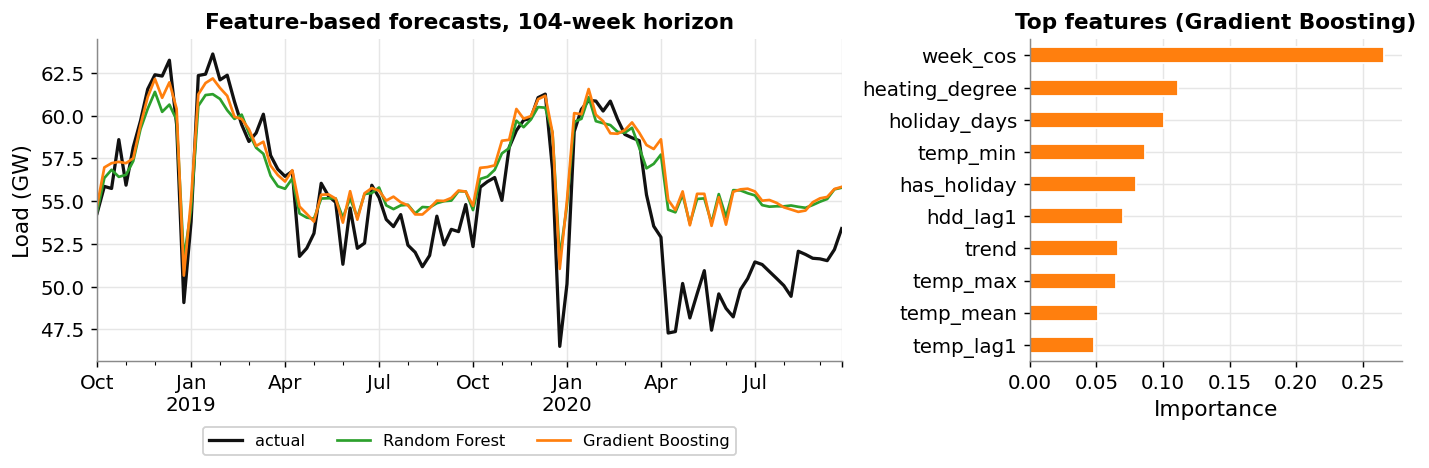

In [47]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [2, 1]})

y_test.plot(ax=ax[0], color="#111111", lw=1.8, label="actual")
forecasts["Random Forest"].plot(ax=ax[0], color="#2ca02c", lw=1.5, label="Random Forest")
forecasts["Gradient Boosting"].plot(ax=ax[0], color="#ff7f0e", lw=1.5, label="Gradient Boosting")
ax[0].set_title("Feature-based forecasts, 104-week horizon")
ax[0].set_ylabel("Load (GW)")
ax[0].set_xlabel("")
ax[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3)

importance = (pd.Series(gb.feature_importances_, index=feature_columns)
                .sort_values().tail(10))
importance.plot(kind="barh", ax=ax[1], color="#ff7f0e", edgecolor="white")
ax[1].set_title("Top features (Gradient Boosting)")
ax[1].set_xlabel("Importance")

tidy(ax)
plt.tight_layout()
plt.show()

---
## Part 6 - LSTM on hourly data

We give the network the last 48 hours of load plus calendar features, and it predicts
the next hour. We then roll that forward across the whole 2-year test period
(**one-step-ahead** forecasting).

Important: this is an easier task than the weekly models are doing. The LSTM always
knows the true load up to the previous hour, while the weekly models forecast 104 weeks
into the future having seen nothing. Keep that in mind when comparing the scores.

In [48]:
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)

LOOKBACK = 48                        # hours of history the network sees
TEST_HOURS = TEST_WEEKS * 168        # same test window as the weekly models

# Building the feature table: load + calendar signals
hourly = pd.DataFrame({"load": load})
t = hourly.index

hourly["hour_sin"] = np.sin(2 * np.pi * t.hour / 24)
hourly["hour_cos"] = np.cos(2 * np.pi * t.hour / 24)
hourly["day_sin"] = np.sin(2 * np.pi * t.dayofweek / 7)
hourly["day_cos"] = np.cos(2 * np.pi * t.dayofweek / 7)
hourly["month_sin"] = np.sin(2 * np.pi * t.month / 12)
hourly["month_cos"] = np.cos(2 * np.pi * t.month / 12)
hourly["weekend"] = (t.dayofweek >= 5).astype(float)
hourly["holiday"] = [1.0 if d.date() in german_holidays else 0.0 for d in t]

n_test = TEST_HOURS
n_val = 168 * 26                     # last 26 weeks of training used for validation
n_train = len(hourly) - n_test - n_val

print("train hours:", n_train, " val:", n_val, " test:", n_test)

train hours: 28561  val: 4368  test: 17472


In [49]:
# Scale the data. The scaler is fitted on the TRAINING rows only,
# otherwise information from the test set would leak in.
scaler = StandardScaler()
scaler.fit(hourly[:n_train])
scaled = scaler.transform(hourly)

load_mean = scaler.mean_[0]
load_std = scaler.scale_[0]

def make_windows(start, end):
    X, y = [], []
    for i in range(max(start, LOOKBACK), end):
        X.append(scaled[i - LOOKBACK:i])   # previous 48 hours
        y.append(scaled[i, 0])             # the load at hour i
    return np.array(X), np.array(y)

X_tr, y_tr = make_windows(0, n_train)
X_va, y_va = make_windows(n_train, n_train + n_val)
X_te, y_te = make_windows(n_train + n_val, len(hourly))

test_index = hourly.index[n_train + n_val:]

print("X_train:", X_tr.shape, " X_val:", X_va.shape, " X_test:", X_te.shape)

X_train: (28513, 48, 9)  X_val: (4368, 48, 9)  X_test: (17472, 48, 9)


### Try a few architectures and keep the best

In [50]:
def build_lstm(units, dropout):
    model = keras.Sequential()
    model.add(keras.Input(shape=(LOOKBACK, X_tr.shape[2])))
    model.add(layers.LSTM(units))
    if dropout > 0:
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1))
    model.compile(optimizer="adam", loss="mse")
    return model

options = [(32, 0.0), (64, 0.1), (64, 0.2), (128, 0.1)]
scores = []

for units, dropout in options:
    model = build_lstm(units, dropout)
    model.fit(X_tr, y_tr, validation_data=(X_va, y_va),
              epochs=3, batch_size=256, verbose=0)

    pred = model.predict(X_va, verbose=0).ravel()
    rmse = np.sqrt(mean_squared_error(y_va * load_std + load_mean,
                                      pred * load_std + load_mean))
    scores.append({"units": units, "dropout": dropout, "val_RMSE": rmse})
    print(f"units={units:3d} dropout={dropout}  ->  validation RMSE = {rmse:.3f} GW")

tuning = pd.DataFrame(scores).sort_values("val_RMSE")
best_units = int(tuning.iloc[0]["units"])
best_dropout = float(tuning.iloc[0]["dropout"])
print("\nbest:", best_units, "units, dropout", best_dropout)

units= 32 dropout=0.0  ->  validation RMSE = 1.159 GW
units= 64 dropout=0.1  ->  validation RMSE = 1.150 GW
units= 64 dropout=0.2  ->  validation RMSE = 1.251 GW
units=128 dropout=0.1  ->  validation RMSE = 0.973 GW

best: 128 units, dropout 0.1


Epoch 1/25
112/112 - 24s - 216ms/step - loss: 0.1319 - val_loss: 0.0211
Epoch 2/25
112/112 - 40s - 358ms/step - loss: 0.0287 - val_loss: 0.0129
Epoch 3/25
112/112 - 23s - 202ms/step - loss: 0.0211 - val_loss: 0.0109
Epoch 4/25
112/112 - 23s - 203ms/step - loss: 0.0169 - val_loss: 0.0093
Epoch 5/25
112/112 - 46s - 409ms/step - loss: 0.0147 - val_loss: 0.0085
Epoch 6/25
112/112 - 23s - 203ms/step - loss: 0.0127 - val_loss: 0.0080
Epoch 7/25
112/112 - 24s - 213ms/step - loss: 0.0120 - val_loss: 0.0069
Epoch 8/25
112/112 - 40s - 354ms/step - loss: 0.0109 - val_loss: 0.0068
Epoch 9/25
112/112 - 22s - 199ms/step - loss: 0.0103 - val_loss: 0.0059
Epoch 10/25
112/112 - 21s - 189ms/step - loss: 0.0095 - val_loss: 0.0060
Epoch 11/25
112/112 - 22s - 200ms/step - loss: 0.0090 - val_loss: 0.0056
Epoch 12/25
112/112 - 23s - 202ms/step - loss: 0.0085 - val_loss: 0.0054
Epoch 13/25
112/112 - 21s - 188ms/step - loss: 0.0083 - val_loss: 0.0052
Epoch 14/25
112/112 - 23s - 202ms/step - loss: 0.0080 - val_

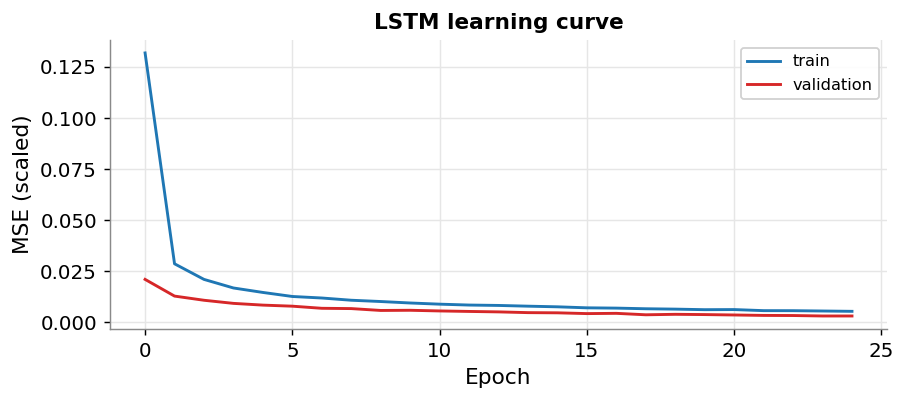

In [51]:
# Training the chosen model properly, stopping early if it starts overfitting
lstm = build_lstm(best_units, best_dropout)

stop_early = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

history = lstm.fit(
    X_tr, y_tr,
    validation_data=(X_va, y_va),
    epochs=25,
    batch_size=256,
    callbacks=[stop_early],
    verbose=2,
)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(history.history["loss"], color="#1f77b4", label="train")
ax.plot(history.history["val_loss"], color="#d62728", label="validation")
ax.set_title("LSTM learning curve")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE (scaled)")
ax.legend()
tidy(ax)
plt.tight_layout()
plt.show()

In [52]:
# Predict every hour of the 2-year test window
pred_scaled = lstm.predict(X_te, verbose=0).ravel()

lstm_pred = pd.Series(pred_scaled * load_std + load_mean, index=test_index)
lstm_actual = pd.Series(y_te * load_std + load_mean, index=test_index)

print("Hourly (one-step-ahead):")
evaluate("LSTM (hourly)", lstm_actual, lstm_pred)

# Average the hourly predictions up to weeks so we can compare with the other models
lstm_weekly = lstm_pred.resample("W").mean()
actual_weekly = lstm_actual.resample("W").mean()
complete = lstm_pred.resample("W").count() >= 167
lstm_weekly, actual_weekly = lstm_weekly[complete], actual_weekly[complete]

forecasts["LSTM"] = lstm_weekly
print("\nAggregated to weekly:")
evaluate("LSTM (weekly avg)", actual_weekly, lstm_weekly, train)

Hourly (one-step-ahead):
LSTM (hourly)           RMSE=0.672  MAE=0.511  MAPE=0.95%  Bias=+0.062

Aggregated to weekly:
LSTM (weekly avg)       RMSE=0.133  MAE=0.108  MAPE=0.20%  Bias=+0.063  MASE=0.080


np.float64(0.1332320807733843)

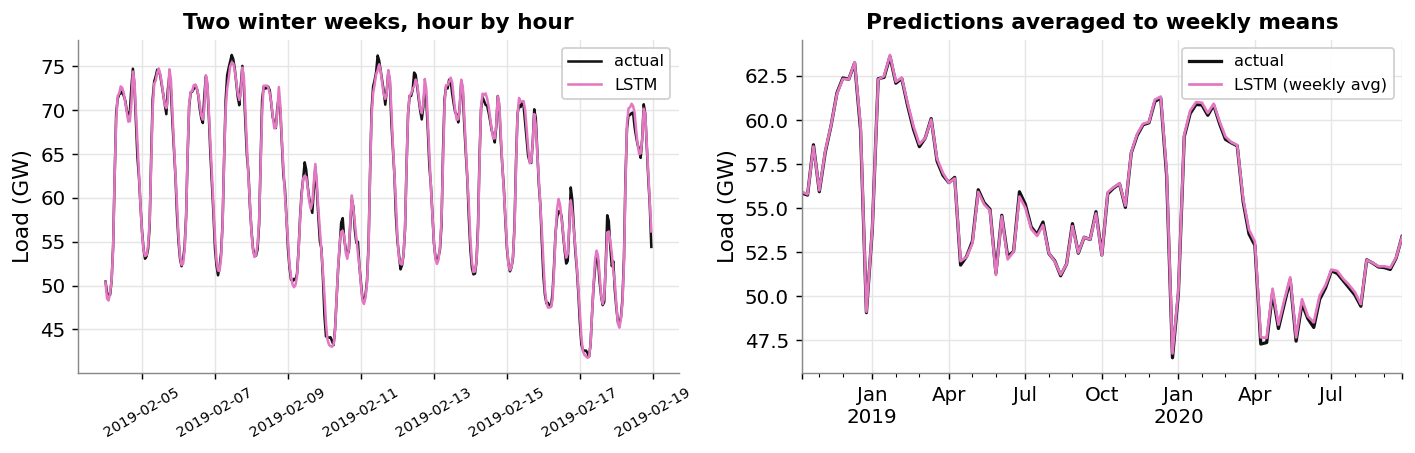

In [53]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

week = slice("2019-02-04", "2019-02-18")
ax[0].plot(lstm_actual[week], color="#111111", lw=1.4, label="actual")
ax[0].plot(lstm_pred[week], color="#e377c2", lw=1.4, label="LSTM")
ax[0].set_title("Two winter weeks, hour by hour")
ax[0].set_ylabel("Load (GW)")
ax[0].set_xlabel("")
ax[0].tick_params(axis="x", rotation=30, labelsize=8)
ax[0].legend(loc="upper right")

actual_weekly.plot(ax=ax[1], color="#111111", lw=1.8, label="actual")
lstm_weekly.plot(ax=ax[1], color="#e377c2", lw=1.5, label="LSTM (weekly avg)")
ax[1].set_title("Predictions averaged to weekly means")
ax[1].set_ylabel("Load (GW)")
ax[1].set_xlabel("")
ax[1].legend(loc="upper right")

tidy(ax)
plt.tight_layout()
plt.show()

### A fairer test: recursive multi-step forecast

The one-step-ahead scores above flatter the LSTM, because at every hour it is
handed the *true* load of the previous 48 hours. A real multi-day forecast has to
feed its **own predictions** back in, so errors accumulate. Below we roll the model
forward two weeks with no real load supplied, over six windows spread across the
test period. The calendar features stay knownonly the load channel is replaced by the model's own output.

In [62]:
# Recursive 2-week forecast, repeated over 6 windows across the test set.
# Only the load channel is fed back; calendar features remain the true future values.
BLOCK = 24 * 14          # 2-week recursive horizon (336 hours)
N_WINDOWS = 6

test_start = n_train + n_val
max_start = len(hourly) - BLOCK
starts = np.linspace(test_start, max_start, N_WINDOWS, dtype=int)

rec_rmses, rec_maes = [], []
rec_example = None

for w, s0 in enumerate(starts, 1):
    window = scaled[s0 - LOOKBACK:s0].copy()      # 48h of real history
    preds_scaled = []

    for step in range(BLOCK):
        x = window.reshape(1, LOOKBACK, scaled.shape[1])
        yhat = lstm.predict(x, verbose=0)[0, 0]   # predicted (scaled) load
        preds_scaled.append(yhat)

        next_row = scaled[s0 + step].copy()       # true calendar features...
        next_row[0] = yhat                        # ...but our own load prediction
        window = np.vstack([window[1:], next_row])

    preds = np.array(preds_scaled) * load_std + load_mean
    actual = scaled[s0:s0 + BLOCK, 0] * load_std + load_mean
    idx = hourly.index[s0:s0 + BLOCK]

    rmse = np.sqrt(mean_squared_error(actual, preds))
    mae = mean_absolute_error(actual, preds)
    rec_rmses.append(rmse)
    rec_maes.append(mae)
    print(f"window {w}/{N_WINDOWS}  starts {idx[0].date()}   RMSE={rmse:.2f}  MAE={mae:.2f}")
    if w == 3:
        rec_example = (idx, actual, preds)

print(f"\nRecursive 2-week forecast, averaged over {N_WINDOWS} windows:")
print(f"  RMSE = {np.mean(rec_rmses):.3f} GW    MAE = {np.mean(rec_maes):.3f} GW")
print(f"  (one-step-ahead RMSE was ~0.75 GW - the gap is exactly the horizon effect)")

window 1/6  starts 2018-10-04   RMSE=1.66  MAE=1.36
window 2/6  starts 2019-02-23   RMSE=3.18  MAE=2.63
window 3/6  starts 2019-07-16   RMSE=1.66  MAE=1.38
window 4/6  starts 2019-12-06   RMSE=4.41  MAE=3.57
window 5/6  starts 2020-04-27   RMSE=4.59  MAE=3.88
window 6/6  starts 2020-09-17   RMSE=1.67  MAE=1.33

Recursive 2-week forecast, averaged over 6 windows:
  RMSE = 2.861 GW    MAE = 2.359 GW
  (one-step-ahead RMSE was ~0.75 GW - the gap is exactly the horizon effect)


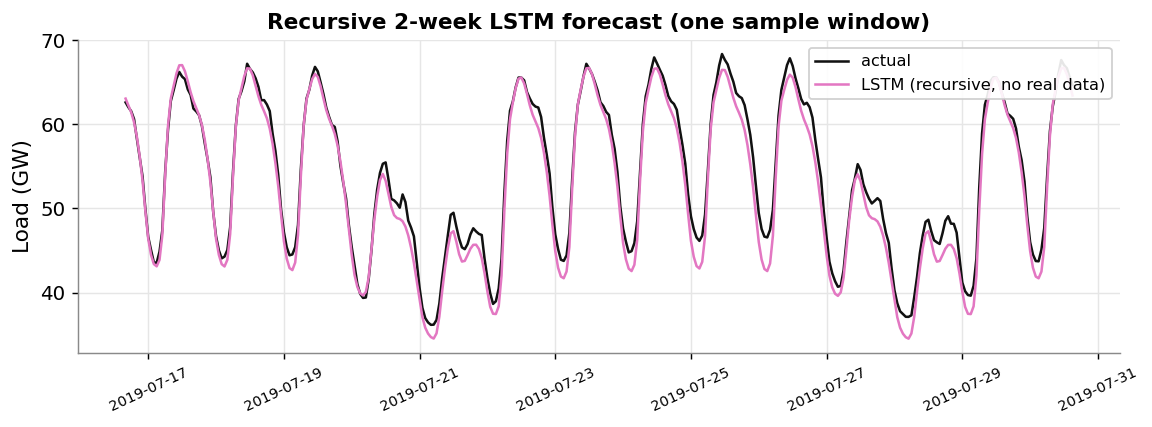

In [64]:
# Show one recursive window: prediction drifting away from the truth over two weeks
idx, actual, preds = rec_example

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(idx, actual, color="#111111", lw=1.4, label="actual")
ax.plot(idx, preds, color="#e377c2", lw=1.4, label="LSTM (recursive, no real data)")
ax.set_title("Recursive 2-week LSTM forecast (one sample window)")
ax.set_ylabel("Load (GW)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=25, labelsize=8)
ax.legend(loc="upper right")
tidy(ax)
plt.tight_layout()
plt.show()

---
## Part 7 - Compare everything

In [65]:
table = pd.DataFrame(results)

# Skill score: how much better (or worse) than seasonal naive?
seasonal_naive_rmse = table.loc[table["Model"] == "Seasonal naive", "RMSE"].iloc[0]
table["Skill vs SN (%)"] = (1 - table["RMSE"] / seasonal_naive_rmse) * 100

print("WARNING: the two LSTM rows are NOT comparable with the rest of the table.")
print("The LSTM forecasts 1 hour ahead knowing the true recent load; every other")
print("model forecasts 104 weeks ahead from a fixed origin. Different problems.")
print()

table.round(3)

The LSTM forecasts 1 hour ahead knowing the true recent load; every other
model forecasts 104 weeks ahead from a fixed origin. Different problems.



,Model,RMSE,MAE,MAPE,Bias,MASE,Skill vs SN (%)
0,Mean,4.513,3.894,7.239,1.148,2.356,-50.878
1,Naive,4.476,3.857,7.154,0.989,2.334,-49.620
2,Seasonal naive,2.991,2.291,4.361,1.748,1.387,0.000
3,Drift,8.011,6.514,12.454,5.278,3.942,-167.790
4,SARIMA,4.029,3.298,6.260,3.134,2.437,-34.678
5,SARIMAX (+temp),3.675,2.928,5.583,2.854,2.163,-22.849
6,Random Forest,2.846,2.154,4.138,1.486,1.591,4.852
7,Gradient Boosting,2.881,2.147,4.144,1.760,1.587,3.696
8,LSTM (hourly),0.672,0.511,0.953,0.062,NaN,77.521
9,LSTM (weekly avg),0.133,0.108,0.201,0.063,0.080,95.546


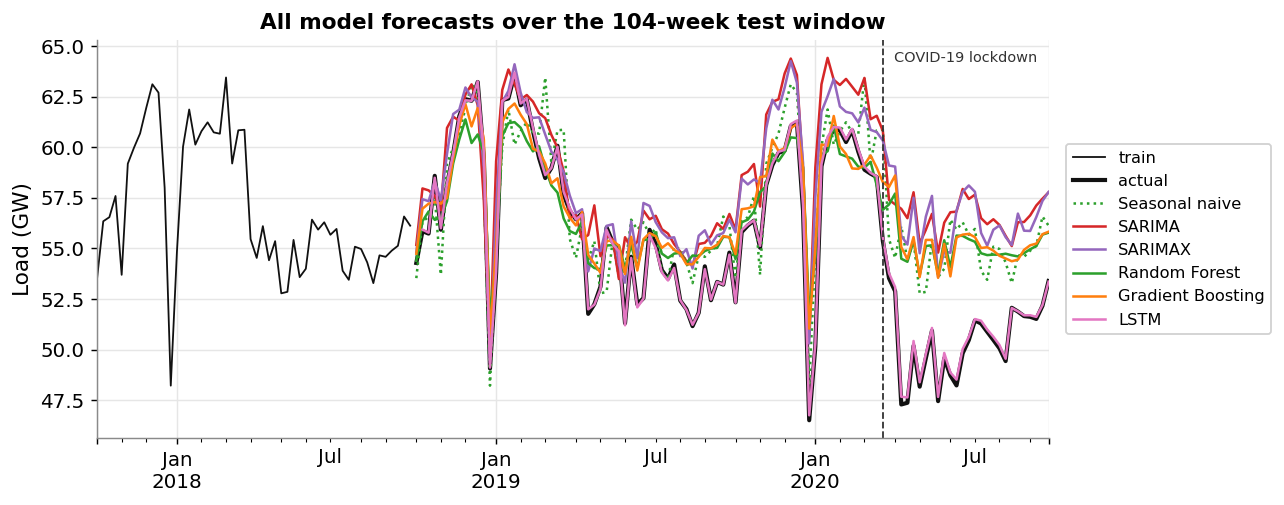

In [66]:
fig, ax = plt.subplots(figsize=(10, 4))

weekly[-TEST_WEEKS - 52:-TEST_WEEKS].plot(ax=ax, color="#111111", lw=1.0, label="train")
test.plot(ax=ax, color="#111111", lw=2.3, label="actual")

plots = [("Seasonal naive", ":"), ("SARIMA", "-"), ("SARIMAX", "-"),
         ("Random Forest", "-"), ("Gradient Boosting", "-"), ("LSTM", "-")]
for name, ls in plots:
    forecasts[name].plot(ax=ax, color=COLORS[name], ls=ls, lw=1.4, label=name)

lockdown = pd.Timestamp("2020-03-16", tz="Europe/Berlin")
ax.axvline(lockdown, color="#333333", ls="--", lw=1)
ax.annotate("COVID-19 lockdown", xy=(lockdown, ax.get_ylim()[1]),
            xytext=(6, -12), textcoords="offset points", fontsize=8, color="#333333")

ax.set_title("All model forecasts over the 104-week test window")
ax.set_ylabel("Load (GW)")
ax.set_xlabel("")
# legend outside on the right - eight entries would otherwise sit on the data
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
tidy(ax)
plt.tight_layout()
plt.show()

### Does COVID explain the poor scores?

The last 28 weeks of the test set are after the March 2020 lockdown. Let's split
the errors and look at each period separately.

In [67]:
lockdown = pd.Timestamp("2020-03-16", tz="Europe/Berlin")
before = test.index < lockdown

rows = []
for name in ["Seasonal naive", "SARIMA", "SARIMAX", "Random Forest", "Gradient Boosting"]:
    f = forecasts[name]
    rows.append({
        "Model": name,
        "RMSE before COVID": np.sqrt(mean_squared_error(test[before], f[before])),
        "RMSE during COVID": np.sqrt(mean_squared_error(test[~before], f[~before])),
    })

covid_table = pd.DataFrame(rows)
print("weeks before lockdown:", before.sum(), " after:", (~before).sum())
covid_table.round(3)

weeks before lockdown: 76  after: 28


,Model,RMSE before COVID,RMSE during COVID
0,Seasonal naive,1.887,4.855
1,SARIMA,2.700,6.364
2,SARIMAX,2.195,6.090
3,Random Forest,1.648,4.767
4,Gradient Boosting,1.568,4.914


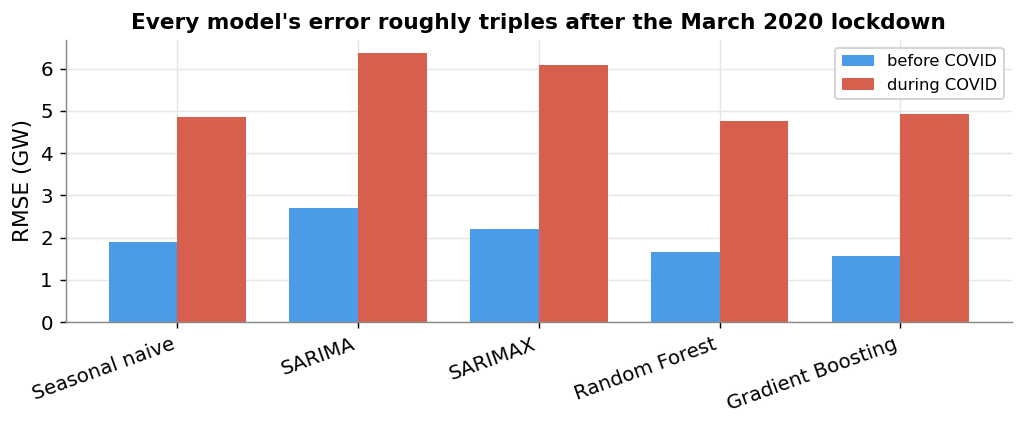

In [68]:
# Showing the before/during-COVID errors side by side
fig, ax = plt.subplots(figsize=(8, 3.4))
x = np.arange(len(covid_table))
w = 0.38
ax.bar(x - w/2, covid_table["RMSE before COVID"], w, label="before COVID", color="#4c9be8")
ax.bar(x + w/2, covid_table["RMSE during COVID"], w, label="during COVID", color="#d6604d")
ax.set_xticks(x)
ax.set_xticklabels(covid_table["Model"], rotation=20, ha="right")
ax.set_ylabel("RMSE (GW)")
ax.set_title("Every model's error roughly triples after the March 2020 lockdown")
ax.legend()
tidy(ax)
plt.tight_layout()
plt.show()

In [69]:
# How much did demand actually drop?
q2_2020 = weekly["2020-04":"2020-06"].mean()
q2_2019 = weekly["2019-04":"2019-06"].mean()
print(f"Q2 2019 average: {q2_2019:.2f} GW")
print(f"Q2 2020 average: {q2_2020:.2f} GW")
print(f"drop: {(q2_2020 / q2_2019 - 1) * 100:.1f}%")

Q2 2019 average: 54.09 GW
Q2 2020 average: 49.28 GW
drop: -8.9%


### Forecast into the future

Finally, refit SARIMA on *all* the data and forecast a year beyond the end of the file.

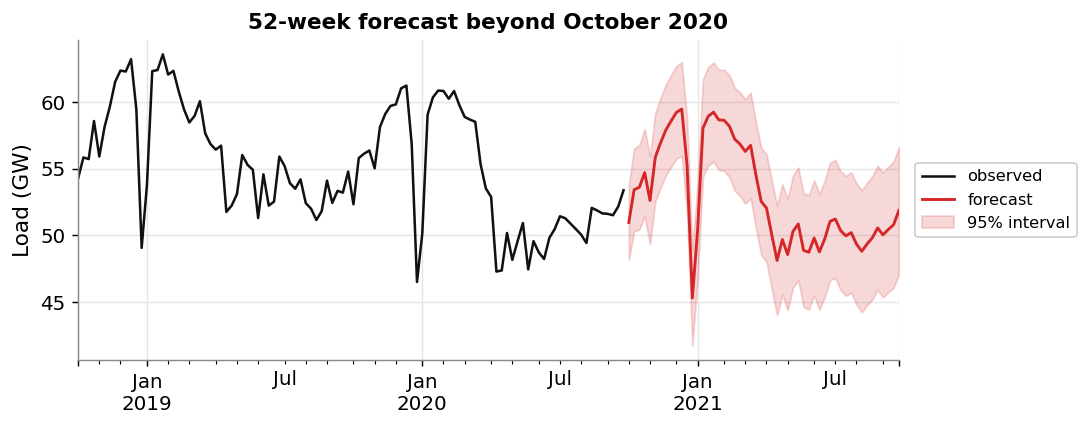

In [70]:
future_model = SARIMAX(
    weekly,
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=200)

future = future_model.get_forecast(steps=52)
future_mean = future.predicted_mean
future_ci = future.conf_int()

fig, ax = plt.subplots(figsize=(8.5, 3.4))
weekly[-104:].plot(ax=ax, color="#111111", lw=1.4, label="observed")
future_mean.plot(ax=ax, color="#d62728", lw=1.6, label="forecast")
ax.fill_between(future_ci.index, future_ci.iloc[:, 0], future_ci.iloc[:, 1],
                color="#d62728", alpha=0.18, label="95% interval")
ax.set_title("52-week forecast beyond October 2020")
ax.set_ylabel("Load (GW)")
ax.set_xlabel("")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
tidy(ax)
plt.tight_layout()
plt.show()

---
## Summary of what i found

- The weekly series is strongly seasonal (annual cycle) with a weak downward trend.
- **Seasonal naive is a hard benchmark to beat** - it scores far better than Mean, Naive or Drift.
- **SARIMA is worse than seasonal naive.** AIC picks the model that fits best one step
  ahead, but we are forecasting 104 steps ahead, where the AR/MA terms have decayed to nothing.
- Adding temperature (SARIMAX) improves SARIMA, but still does not beat the benchmark.
- **Random Forest is the only model that beats seasonal naive** over the full test window.
- The **LSTM scores look amazing but are not comparable** - it forecasts one hour ahead
  knowing the true recent load, which is a much easier problem.
- COVID-19 dominates the last 28 weeks of the test set. Before the lockdown the tree
  models beat the benchmark by ~11%; afterwards every model's error roughly triples.